# SysSim — ARIA Tutorial (2026-05-22)

SysSim (https://github.com/AISysSim/SysSim) estimates the step time and peak memory of LLM training on hardware
you don't have, without running real computation. This notebook walks through five sections:

1. **Getting Started** — install → (profile) → calibrate → headline Qwen3-8B vs. Llama-3-8B on GH200, checked against real measurements
2. **Configs** — Batch / Seqlen / TP / PP sweeps
3. **GPU vendor** — AMD MI300X (roofline → trained predictor)
4. **Precision** — FP8 (roofline → trained predictor)
5. **Accelerator integration** — custom estimator via `HardwareConfig(estimator=...)`

**Before you run anything:** _Runtime → Change runtime type → T4 GPU_.
(If the install cell fails on T4, fall back to L4 or A100.)

In [1]:
import torch
assert torch.cuda.is_available(), (
    "SysSim requires a GPU runtime. "
    "Runtime → Change runtime type → T4 GPU (or L4/A100), then re-run."
)
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA GH200 120GB


## §1. Getting Started

This section is the recommended path for a first run of SysSim: **install → (profile) → calibrate → simulate**. By the end you'll have run the calibrated GH200 cost model on two real models.

### Step 1 — Installation

Clone SysSim (with submodules) and install it into the Colab runtime. This is the only step here that performs a heavy install; it takes ~3–5 minutes on a fresh runtime.

In [2]:
import os, subprocess
import logging, warnings

# Silence benign Megatron / Apex / RNG warnings so the demo output stays readable.
logging.getLogger("megatron.core.tensor_parallel.random").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="CPU RNG state changed within GPU RNG context")
warnings.filterwarnings("ignore", message="Module is None. Skipping .* hook.")
warnings.filterwarnings("ignore", message="Apex is not installed.*")
warnings.filterwarnings("ignore", message="full scope is deprecated.*")

# 1) Clone SysSim (master, with submodules) into the Colab runtime.
if not os.path.exists("SysSim") and not os.path.basename(os.getcwd()) == "SysSim":
    subprocess.run(
        "git clone --recurse-submodules https://github.com/AISysSim/SysSim.git",
        shell=True, check=True,
    )

if os.path.basename(os.getcwd()) != "SysSim":
    %cd SysSim

# 2) Make the editable install work on Colab.
#    The repo root holds several top-level dirs (data/, syssim/, third_party/),
#    so setuptools' flat-layout auto-discovery refuses to guess. Scope it to the
#    syssim package explicitly. (Runtime-only tweak; the repo is unchanged upstream.)
_pp = "pyproject.toml"
_txt = open(_pp).read()
if "tool.setuptools.packages.find" not in _txt:
    with open(_pp, "a") as _f:
        _f.write('\n[tool.setuptools.packages.find]\ninclude = ["syssim*"]\n')

# 3) Install the two SysSim deps that aren't already on a Colab runtime.
#    Everything else SysSim needs (numpy, pandas, pyarrow, pyyaml, scikit-learn,
#    torch, transformers) ships with Colab. We also skip megatron-bridge and
#    flashinfer-python: they don't build on a T4 and aren't used by this demo.
!pip install -q lightgbm megatron-core 2>&1 | tail -3

# 4) Install SysSim itself (editable, no dep re-resolution).
!pip install -q --no-deps -e . 2>&1 | tail -3

import syssim
print(f"SysSim {syssim.__version__ if hasattr(syssim,'__version__') else ''} imported from: {syssim.__file__}")

  DEPRECATION: Setting PIP_CONSTRAINT will not affect build constraints in the future, pip 26.2 will enforce this behaviour change. A possible replacement is to specify build constraints using --build-constraint or PIP_BUILD_CONSTRAINT. To disable this warning without any build constraints set --use-feature=build-constraint or PIP_USE_FEATURE="build-constraint".


SysSim  imported from: /lus/lfs1aip2/projects/u6kg/mksit/SysSim/syssim/__init__.py


### Step 2 — Profiling (shown, not run here)

Profiling measures the **real GPU self-time** of every operator a Megatron transformer layer dispatches, across SysSim's architecture/shape space, and writes them to `data/<device>/profile.parquet`. These measurements are what calibrates the per-operator cost model.

Profiling needs the **actual target GPUs** (real kernels on the real device), so it is **not run in this notebook** — Colab's T4 is not a GH200. The real command on a 4-GPU GH200 node is:

```bash
python -m syssim profile --out data/gh200 --num-workers 4
```

In [3]:
# DRY RUN ONLY — previews the profiling job list (layer configs x tensor-parallel
# shapes). It does NOT profile and does NOT touch the GPU. Real profiling needs the
# target GH200 GPUs; we ship data/gh200/profile.parquet so you can skip it.
!python -m syssim profile --out data/gh200 --dry-run

dry run: 158 layer-config jobs (42 configs x tensor-parallel [1, 2, 4, 8], divisible only); seq points [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


### Step 3 — Calibration

Calibration fits the per-operator cost model from the shipped profile. For each operator family (GEMM, elementwise, reduction) it learns a small LightGBM **residual** — `log(measured_time / roofline_anchor)` as a function of op size — on top of the roofline floor. This is **CPU-only**, so it runs fine here on Colab.

It reads `data/gh200/profile.parquet` and writes the per-family models (`gemm_model.lgb`, `elementwise_model.lgb`, `reduction_model.lgb`) plus `manifest.json` into `data/gh200/`.

In [4]:
# Fit the per-family residual trees from the shipped GH200 profile (CPU-only).
# Writes gemm/elementwise/reduction *.lgb + manifest.json into data/gh200/.
!python -m syssim calibrate --data data/gh200 --hardware examples/configs/hardware/isambard_gh200_4gpu.yaml

calibrate: loaded 23016 (op, shape) rows from data/gh200/profile.parquet


calibrate: built feature codes (22 op subtypes); families = gemm, elementwise, reduction
calibrate: fitting gemm ...


calibrate: gemm done -> median_ape=6.2%  p95=64.3%  (train=4573 val=1265)
calibrate: fitting elementwise ...


calibrate: elementwise done -> median_ape=6.0%  p95=44.6%  (train=10856 val=2045)
calibrate: fitting reduction ...


calibrate: reduction done -> median_ape=4.6%  p95=19.3%  (train=3831 val=446)
calibrated 3 families -> data/gh200 (gemm_model.lgb, elementwise_model.lgb, reduction_model.lgb + manifest.json)


### Step 4 — Headline: SysSim vs. real GH200 (Qwen3-8B & Llama-3-8B)

Now run the simulator with the **Python API** and check it against **real Megatron-core measurements** on GH200. The measured numbers come from `docs/megatron_gh200_validation/` (the published reference runs), and the hardware YAMLs carry `calibrated_model: data/gh200` so `simulate(...)` uses the GH200-calibrated cost model you built in Step 3.

Across the full validation suite — 16 single-node + 8 multi-node (2- and 4-node) cases — SysSim lands **within 10% on 24/24** (mean step-time error ~4%). The two sub-sections below show the **single-node** and **multi-node** slices.

#### Single-node — one 4-GPU GH200

`tp2` (TP=2) and `dp4` (DP=4) on a single node, bf16, full recompute. `dp4` uses Megatron's distributed optimizer (ZeRO-1) to shard optimizer state across the 4 data-parallel ranks.

     model case  sim_ms  real_ms  step_err_%  sim_gb  real_gb  mem_err_%
  Qwen3-8B  tp2   633.5    694.8         8.8    66.5     64.6        2.8
  Qwen3-8B  dp4  1160.9   1157.3         0.3    69.1     65.8        5.0
Llama-3-8B  tp2  1776.7   1842.4         3.6    69.5     69.4        0.1
Llama-3-8B  dp4  3243.4   3360.2         3.5    79.9     79.9        0.0

Max step-time error: 8.8%  |  Max memory error: 5.0%  (target: within 10%)


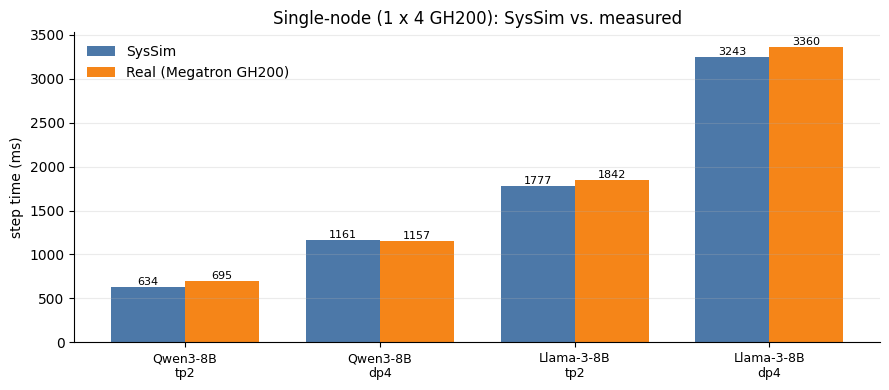

In [5]:
import syssim
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

HW_1NODE = "examples/configs/hardware/isambard_gh200_4gpu.yaml"   # 1 node, 4 GPUs (calibrated_model: data/gh200)
HW_4NODE = "examples/configs/hardware/isambard_gh200_4node.yaml"  # 4 nodes, 16 GPUs (+ inter-node Slingshot)
MODELS = {
    "Qwen3-8B": "examples/configs/models/qwen3-8b.yaml",
    "Llama-3-8B": "examples/megatron/llama3-8b.yaml",
}

def headline_compare(cases, title):
    """Run each case through SysSim, tabulate vs. measured GH200, and bar-chart step time."""
    rows = []
    for model_name in MODELS:
        for case, cfg in cases[model_name].items():
            r = syssim.simulate(
                model=MODELS[model_name], hardware=cfg["hw"],
                parallelism=syssim.ParallelismConfig(tp=cfg["tp"], dp=cfg["dp"]),
                training=syssim.TrainingConfig(
                    micro_batch=cfg["micro_batch"], global_batch=cfg["global_batch"],
                    dtype="bf16", recompute="full",
                    use_distributed_optimizer=cfg["distopt"]),
            )
            rows.append({
                "model": model_name, "case": case,
                "sim_ms": round(r.step_time_ms, 1), "real_ms": cfg["real_ms"],
                "step_err_%": round(100 * abs(r.step_time_ms - cfg["real_ms"]) / cfg["real_ms"], 1),
                "sim_gb": round(r.peak_memory_gb, 1), "real_gb": round(cfg["real_gb"], 1),
                "mem_err_%": round(100 * abs(r.peak_memory_gb - cfg["real_gb"]) / cfg["real_gb"], 1),
            })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print(f"\nMax step-time error: {df['step_err_%'].max():.1f}%  |  "
          f"Max memory error: {df['mem_err_%'].max():.1f}%  (target: within 10%)")

    labels = [f"{m}\n{c}" for m, c in zip(df["model"], df["case"])]
    x = range(len(df)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar([i - w/2 for i in x], df["sim_ms"], width=w, label="SysSim", color="#4C78A8")
    ax.bar([i + w/2 for i in x], df["real_ms"], width=w, label="Real (Megatron GH200)", color="#F58518")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("step time (ms)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
    for i, (s, rl) in enumerate(zip(df["sim_ms"], df["real_ms"])):
        ax.text(i - w/2, s, f"{s:.0f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w/2, rl, f"{rl:.0f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()
    return df

# Single-node: one 4-GPU GH200.
SINGLE_NODE = {
    "Qwen3-8B": {
        "tp2": dict(hw=HW_1NODE, tp=2, dp=1, micro_batch=1, global_batch=1, distopt=False, real_ms=694.8,  real_gb=64.63),
        "dp4": dict(hw=HW_1NODE, tp=1, dp=4, micro_batch=1, global_batch=4, distopt=True,  real_ms=1157.3, real_gb=65.84),
    },
    "Llama-3-8B": {
        "tp2": dict(hw=HW_1NODE, tp=2, dp=1, micro_batch=1, global_batch=1, distopt=False, real_ms=1842.4, real_gb=69.41),
        "dp4": dict(hw=HW_1NODE, tp=1, dp=4, micro_batch=1, global_batch=4, distopt=True,  real_ms=3360.2, real_gb=79.93),
    },
}
cmp_single = headline_compare(SINGLE_NODE, "Single-node (1 x 4 GH200): SysSim vs. measured")

#### Multi-node — 4 nodes × 4 GPUs (16 GPUs)

`tp4dp4` (TP=4 × DP=4) fanned across 4 GH200 nodes. SysSim simulates the inter-node Slingshot fabric, so this runs on the **same single Colab GPU** — no real multi-node job is required. (Reuses `headline_compare` from the single-node cell.)

     model         case  sim_ms  real_ms  step_err_%  sim_gb  real_gb  mem_err_%
  Qwen3-8B 4node tp4dp4   483.9    472.1         2.5    19.7     18.7        5.4
Llama-3-8B 4node tp4dp4  1117.4   1053.6         6.1    22.4     22.1        1.2

Max step-time error: 6.1%  |  Max memory error: 5.4%  (target: within 10%)


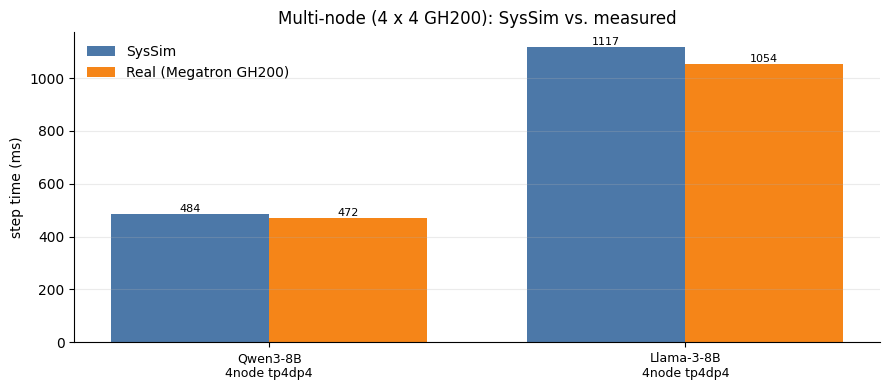

In [6]:
# Multi-node: 4 nodes x 4 GPUs = 16 GPUs (TP=4 x DP=4). SysSim models the inter-node
# Slingshot fabric, so this still runs on the single Colab GPU -- no real cluster needed.
MULTI_NODE = {
    "Qwen3-8B": {
        "4node tp4dp4": dict(hw=HW_4NODE, tp=4, dp=4, micro_batch=1, global_batch=4, distopt=True, real_ms=472.1,  real_gb=18.69),
    },
    "Llama-3-8B": {
        "4node tp4dp4": dict(hw=HW_4NODE, tp=4, dp=4, micro_batch=1, global_batch=4, distopt=True, real_ms=1053.6, real_gb=22.15),
    },
}
cmp_multi = headline_compare(MULTI_NODE, "Multi-node (4 x 4 GH200): SysSim vs. measured")

## §2. Configs — Batch / Seqlen / TP / PP

Hold model = Qwen3-8B and HW = H100 DGX fixed. Sweep one knob at a time.

In [ ]:
def run_sweep(axis_label, axis_key, values):
    rows = []
    for v in values:
        par = syssim.ParallelismConfig(tp=2, dp=4)
        tr = syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="bf16")
        if axis_key == "micro_batch":
            tr = syssim.TrainingConfig(micro_batch=v, global_batch=max(8, v*4), dtype="bf16")
        elif axis_key == "tp":
            par = syssim.ParallelismConfig(tp=v, dp=8 // v)
        elif axis_key == "pp":
            par = syssim.ParallelismConfig(pp=v, dp=8 // v)
        # NOTE: seq_length sweep below requires generating temp model YAMLs
        # because seq_length lives in the model YAML, not TrainingConfig.
        r = syssim.simulate(model=QWEN3, hardware=HW, parallelism=par, training=tr)
        rows.append({axis_label: v, "step_time_ms": round(r.step_time_ms, 2),
                     "peak_memory_gb": round(r.peak_memory_gb, 2), "mfu": round(r.mfu, 3)})
    df = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, metric, title in [
        (axes[0], "step_time_ms", "Step time (ms)"),
        (axes[1], "peak_memory_gb", "Peak memory (GB)"),
        (axes[2], "mfu", "MFU"),
    ]:
        ax.plot([str(v) for v in df[axis_label]], df[metric], marker="o", linewidth=2)
        ax.set_xlabel(axis_label)
        ax.set_title(title)
        ax.grid(alpha=0.25)
    fig.suptitle(f"Sweep: {axis_label}", y=1.03)
    fig.tight_layout()
    plt.show()
    return df

sweep_tables = {}
for label, key, vals in [
    ("micro_batch", "micro_batch", [1, 2, 4]),
    ("TP",          "tp",          [1, 2, 4]),
    ("PP",          "pp",          [1, 2, 4]),
]:
    print(f"\n=== Sweep: {label} ===")
    sweep_tables[label] = run_sweep(label, key, vals)
    display(sweep_tables[label])

In [ ]:
# Seqlen sweep: generate temp model YAMLs with different seq_length values
import tempfile, yaml
from pathlib import Path

with open(QWEN3) as _f:
    base_cfg = yaml.safe_load(_f)
seq_rows = []
with tempfile.TemporaryDirectory() as tmp:
    for seq in (2048, 4096, 8192):
        cfg = dict(base_cfg); cfg["seq_length"] = seq
        path = Path(tmp) / f"qwen3-8b_seq{seq}.yaml"
        path.write_text(yaml.dump(cfg))
        r = syssim.simulate(model=str(path), hardware=HW,
                            parallelism=syssim.ParallelismConfig(tp=2, dp=4),
                            training=syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="bf16"))
        seq_rows.append({"seq_length": seq, "step_time_ms": round(r.step_time_ms, 2),
                         "mfu": round(r.mfu, 3)})

seq_df = pd.DataFrame(seq_rows)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot([str(v) for v in seq_df["seq_length"]], seq_df["step_time_ms"], marker="o", linewidth=2)
axes[0].set_xlabel("seq_length"); axes[0].set_title("Step time (ms)"); axes[0].grid(alpha=0.25)
axes[1].plot([str(v) for v in seq_df["seq_length"]], seq_df["mfu"], marker="o", linewidth=2)
axes[1].set_xlabel("seq_length"); axes[1].set_title("MFU"); axes[1].grid(alpha=0.25)
fig.suptitle("Sweep: seq_length", y=1.03)
fig.tight_layout()
plt.show()
seq_df

## §3. GPU vendor — AMD MI300X (Mike)

Three sub-demos:
1. **Roofline-only** on `mi300x.yaml`
2. **Synthesize MI300X profiling CSVs** in-cell
3. **Train predictor → re-run**, compare Roofline vs. Trained

Because we're running on a Colab GPU that isn't MI300X, we use a
`simulated_hardware()` context manager (defined in `demo/helpers.py`)
to override SysSim's hardware auto-detection while training the predictor.
In production you'd profile on the actual MI300X and skip the override.

In [ ]:
# §3a: Roofline-only
MI300X = "demo/configs/hardware/mi300x.yaml"
PAR_MI = syssim.ParallelismConfig(tp=8)

print("=== MI300X — Roofline-only (no efficiency model) ===")
r_roof_mi = syssim.simulate(model=QWEN3, hardware=MI300X, parallelism=PAR_MI, training=TR)
print(f"step_time_ms={r_roof_mi.step_time_ms:.2f}  mfu={r_roof_mi.mfu:.3f}  "
      f"peak_mem_gb={r_roof_mi.peak_memory_gb:.2f}")
roofline_ms_mi = r_roof_mi.step_time_ms
mi_roofline_df = pd.DataFrame([{
    "target": "MI300X roofline",
    "step_time_ms": round(r_roof_mi.step_time_ms, 2),
    "mfu": round(r_roof_mi.mfu, 3),
    "peak_memory_gb": round(r_roof_mi.peak_memory_gb, 2),
}])
display(mi_roofline_df)

In [ ]:
# §3b: Synthesize MI300X profiling data
import tempfile
from pathlib import Path

MI300X_PEAKS = {
    "peak_tflops_mm": 1307.0, "peak_tflops_math": 163.4,
    "peak_memory_bandwidth_gbps": 5300.0, "peak_tflops_mm_fp8": 2615.0,
    "peak_tflops_mm_fp4": None,
}

PROF_DIR_MI = Path(tempfile.mkdtemp(prefix="mi300x_profiling_"))
helpers.synthesize_gemm_csv(PROF_DIR_MI / "gemm_mi300x_fp16_data.csv",
                            peak_tflops=1307, peak_bw_GBps=5300, dtype_bytes=2)
helpers.synthesize_attn_csv(PROF_DIR_MI / "attn_mi300x_fp16_data.csv",
                            peak_tflops=1307, peak_bw_GBps=5300, dtype_bytes=2)
helpers.synthesize_rmsnorm_csv(PROF_DIR_MI / "rmsnorm_mi300x_fp16_data.csv",
                               peak_bw_GBps=5300, dtype_bytes=2)
print(f"Wrote profiling CSVs to {PROF_DIR_MI}:")
profile_rows = []
for p in sorted(PROF_DIR_MI.glob("*.csv")):
    row_count = len(pd.read_csv(p))
    profile_rows.append({"file": p.name, "rows": row_count, "size_kb": round(p.stat().st_size / 1024, 1)})
    print(f"  {p.name}  ({p.stat().st_size} bytes, {row_count} rows)")

profile_df_mi = pd.DataFrame(profile_rows)
display(profile_df_mi)

In [ ]:
# §3c: Train predictor → swap → re-simulate
from syssim.compute.compute_cost_profiler import train_efficiency_model
from syssim.api import set_efficiency_model_dir

MODEL_DIR_MI = Path(tempfile.mkdtemp(prefix="mi300x_models_"))

try:
    with helpers.simulated_hardware("mi300x", MI300X_PEAKS) as (_, hw_name):
        train_efficiency_model(
            "gemm", PROF_DIR_MI / "gemm_mi300x_fp16_data.csv",
            str(MODEL_DIR_MI / f"gemm_{hw_name}_fp16_xgb.pth"),
            backend="xgboost", dtype="fp16",
        )
        train_efficiency_model(
            "attn", PROF_DIR_MI / "attn_mi300x_fp16_data.csv",
            str(MODEL_DIR_MI / f"attn_{hw_name}_fp16_xgb.pth"),
            backend="xgboost", dtype="fp16",
        )
        train_efficiency_model(
            "rmsnorm", PROF_DIR_MI / "rmsnorm_mi300x_fp16_data.csv",
            str(MODEL_DIR_MI / f"rmsnorm_{hw_name}_fp16_xgb.pth"),
            backend="xgboost", dtype="fp16",
        )
        set_efficiency_model_dir(str(MODEL_DIR_MI))

        r_trained_mi = syssim.simulate(model=QWEN3, hardware=MI300X,
                                       parallelism=PAR_MI, training=TR)
        trained_ms_mi = r_trained_mi.step_time_ms
finally:
    set_efficiency_model_dir("")

mi_compare_df = pd.DataFrame([
    {"estimator": "Roofline-only", "step_time_ms": round(roofline_ms_mi, 2), "delta_pct": "—"},
    {"estimator": "Trained predictor (synth)",
     "step_time_ms": round(trained_ms_mi, 2),
     "delta_pct": f"{100 * (trained_ms_mi - roofline_ms_mi) / roofline_ms_mi:+.1f}%"},
])
display(mi_compare_df)
fig, ax = plt.subplots(figsize=(6, 3))
colors = ["#4C78A8", "#F58518"]
ax.bar(mi_compare_df["estimator"], mi_compare_df["step_time_ms"], color=colors)
ax.set_ylabel("step_time_ms")
ax.set_title("MI300X roofline vs. learned predictor")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
mi_compare_df

## §4. Precision FP8 (Dayou)

Same workflow as §3, but the dimension is precision rather than vendor.
H100's `peak_tflops_mm_fp8` (3958) gives ~2× throughput vs bf16.

In [ ]:
# §4a: FP8 roofline
TR_FP8 = syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="fp8")

print("=== H100 FP8 — Roofline-only ===")
r_roof_fp8 = syssim.simulate(model=QWEN3, hardware=HW, parallelism=PAR, training=TR_FP8)
print(f"step_time_ms={r_roof_fp8.step_time_ms:.2f}  mfu={r_roof_fp8.mfu:.3f}  "
      f"peak_mem_gb={r_roof_fp8.peak_memory_gb:.2f}")
roofline_ms_fp8 = r_roof_fp8.step_time_ms

In [ ]:
# §4b: Load measured H100 FP8 profiling data
import pandas as pd
from pathlib import Path

H100_FP8_PEAKS = {
    "peak_tflops_mm": 1979.0, "peak_tflops_math": 989.0,
    "peak_memory_bandwidth_gbps": 3350.0, "peak_tflops_mm_fp8": 3958.0,
    "peak_tflops_mm_fp4": None,
}

PROF_DIR_FP8 = Path("data/profiling")
GEMM_FP8_CSV = PROF_DIR_FP8 / "gemm_h100_fp8_data.csv"
ATTN_FP8_CSV = PROF_DIR_FP8 / "attn_h100_fp8_data.csv"

for csv_path in (GEMM_FP8_CSV, ATTN_FP8_CSV):
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing measured FP8 profiling data: {csv_path}")

print("Using measured FP8 profiling CSVs:")
for csv_path in (GEMM_FP8_CSV, ATTN_FP8_CSV):
    print(f"  {csv_path}  ({len(pd.read_csv(csv_path))} rows)")

In [ ]:
# §4c: Train FP8 predictor → swap → re-simulate
import os
MODEL_DIR_FP8 = Path(tempfile.mkdtemp(prefix="h100_fp8_models_"))

try:
    with helpers.simulated_hardware("h100", H100_FP8_PEAKS) as (_, hw_name):
        train_efficiency_model(
            "gemm", GEMM_FP8_CSV,
            str(MODEL_DIR_FP8 / f"gemm_{hw_name}_fp8_xgb.pth"),
            backend="xgboost", dtype="fp8",
        )
        train_efficiency_model(
            "attn", ATTN_FP8_CSV,
            str(MODEL_DIR_FP8 / f"attn_{hw_name}_fp8_xgb.pth"),
            backend="xgboost", dtype="fp8",
        )
        set_efficiency_model_dir(str(MODEL_DIR_FP8))
        os.environ["SYSSIM_FORCE_DTYPE"] = "fp8"
        try:
            r_trained_fp8 = syssim.simulate(model=QWEN3, hardware=HW,
                                            parallelism=PAR, training=TR_FP8)
            trained_ms_fp8 = r_trained_fp8.step_time_ms
        finally:
            del os.environ["SYSSIM_FORCE_DTYPE"]
finally:
    set_efficiency_model_dir("")  # reset for §5

pd.DataFrame([
    {"estimator": "FP8 Roofline-only", "step_time_ms": round(roofline_ms_fp8, 2), "delta_pct": "—"},
    {"estimator": "FP8 Trained predictor (measured)",
     "step_time_ms": round(trained_ms_fp8, 2),
     "delta_pct": f"{100 * (trained_ms_fp8 - roofline_ms_fp8) / roofline_ms_fp8:+.1f}%"},
])

## §5. Accelerator integration — custom estimator (Dayou)

SysSim routes per-operator timing through the Estimator protocol. A custom accelerator plugs in by constructing an estimator and attaching it to `HardwareConfig(estimator=...)`; the tracing and training simulator entry point stays the same.

This demo reuses the Qwen3 YAML model config from the earlier sections and runs it with a custom accelerator estimator.

In [ ]:
# Build a custom-accelerator HardwareConfig
from pathlib import Path
import tempfile
import time

from syssim.external.plena import PLENAConfig, PLENAEstimator
from syssim.training.spec import HardwareConfig, load_model_yaml

PLENA_SETTINGS = Path("third_party/PLENA_Simulator/plena_settings.toml")
PLENA_ISA = Path("third_party/PLENA_Simulator/analytic_models/performance/customISA_lib.json")
if not PLENA_SETTINGS.exists() or not PLENA_ISA.exists():
    raise FileNotFoundError(
        "PLENA_Simulator submodule is missing. Run `git submodule update --init --recursive`."
    )

plena_config = PLENAConfig.from_plena_submodule(frequency_hz=1.0e9)
plena_estimator = PLENAEstimator(plena_config)

plena_hw = HardwareConfig(
    peak_tflops_mm=1979,
    peak_tflops_math=989,
    peak_memory_bandwidth_GBps=3350,
    gpus_per_node=1,
    gpu_memory_GB=80,
    topology={
        "type": "simple",
        "num_nodes": 1,
        "intra_node_bandwidth_GBps": 900,
        "inter_node_bandwidth_GBps": 200,
    },
    estimator=plena_estimator,
)

# Reuse the same Qwen3 model YAML used in the earlier demos.
QWEN3 = globals().get("QWEN3", "examples/configs/models/qwen3-8b.yaml")
plena_model = load_model_yaml(QWEN3)

print(f"Estimator: {type(plena_hw.estimator).__name__}")
print(f"Model config: {QWEN3}")
print(f"Config: {PLENA_SETTINGS}")


In [ ]:
# Run the same training simulator with accelerator-backed op estimates
start = time.time()
r_plena = syssim.simulate(
    model=plena_model,
    hardware=plena_hw,
    parallelism=syssim.ParallelismConfig(tp=1, dp=1),
    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"),
    workdir=tempfile.mkdtemp(prefix="plena_demo_"),
)
host_elapsed_s = time.time() - start

pd.DataFrame([
    {
        "estimator": type(plena_hw.estimator).__name__,
        "host_elapsed_s": round(host_elapsed_s, 2),
        "step_time_ms": round(r_plena.step_time_ms, 4),
        "forward_ms": round(r_plena.forward_ms, 4),
        "backward_ms": round(r_plena.backward_ms, 4),
        "peak_memory_gb": round(r_plena.peak_memory_gb, 4),
        "dominant_op_type": max(r_plena.by_op_type_ms, key=r_plena.by_op_type_ms.get),
    }
])

The key integration point is the `estimator` field on `HardwareConfig`. The simulator does not need a separate code path for the accelerator: traced operators call the configured estimator, and the stream-queue runtime consumes the resulting per-op timings.

In [ ]:
import importlib.util as u
for m in ['transformer_engine','apex','flash_attn','megatron.core','syssim.training']:
    print(m, 'present' if u.find_spec(m) else 'ABSENT')
# does simulate work end to end despite TE/Apex absent?
import syssim, warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    r = syssim.simulate(model='examples/configs/models/qwen3-8b.yaml',
                        hardware='examples/configs/hardware/isambard_gh200_4gpu.yaml',
                        parallelism=syssim.ParallelismConfig(tp=2, dp=1),
                        training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype='bf16', recompute='full'))
print('OK step_ms=%.1f peak_gb=%.2f' % (r.step_time_ms, r.peak_memory_gb))